In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [2]:
df_default = pd.read_csv('experiment_metrics_fully_parallel/default1.csv')
df_default['Config'] = 'Adam 1e-5'

df2 = pd.read_csv('experiment_metrics_fully_parallel/lr_init-1e-3.csv')
df2['Config'] = 'Adam 1e-3'

df3 = pd.read_csv('experiment_metrics_fully_parallel/lr_init-1e-4.csv')
df3['Config'] = 'Adam 1e-4'

df4 = pd.read_csv('experiment_metrics_fully_parallel/SGD.csv')
df4['Config'] = 'SGD 1e-5'

mdf = pd.concat([df_default, df2, df3, df4], ignore_index=True)
print(mdf.columns)

Index(['val/total_mse', 'train/grad_norm', 'train/forces_magnitude_error',
       'train/lr', 'train/epoch', 'train/energy_mae', '_timestamp',
       'val/forces_mae', 'val/energy_mse', 'train/forces_mse',
       'train/energy_rmse', 'train/energy_forces_within_threshold',
       'val/forces_rmse', 'val/energy_mae', 'train/energy_mse',
       'val/energy_rmse', 'val/forces_cosine_similarity',
       'train/forces_cosine_similarity', 'train/step',
       'val/pct_loss_from_equiv_error', '_runtime', 'train/forces_mae',
       'val/loss', 'val/mean_pred_error', 'val/epoch',
       'val/energy_forces_within_threshold', 'train/loss', 'val/forces_mse',
       'val/forces_magnitude_error', 'train/forces_rmse', '_step',
       'val/equiv_error', 'Config', 'val/mean_pred_grad_norm',
       'val/grad_norm_ratio_equiv_over_mean', 'val/equiv_grad_norm'],
      dtype='object')


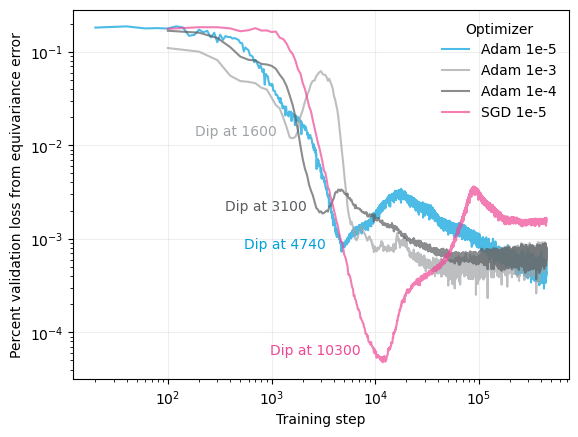

In [9]:
color_palette = {
    'Adam 1e-5': '#00a0dc',
    'Adam 1e-4': '#595c5f',
    'Adam 1e-3': '#a0a3a6',
    'SGD 1e-5': '#ed4795',
}

sns.lineplot(
    data=mdf,
    x='_step',
    y='val/pct_loss_from_equiv_error',
    hue = 'Config',
    palette = color_palette,
    errorbar = None,
    alpha=0.7,
)

# for each config, add text indicating the minimum value of 'val/pct_loss_from_equiv_error' before step 11000
for config in mdf['Config'].unique():
    threshold_step = 11000
    if config == 'Adam 1e-3':
        threshold_step = 2000
    if config == 'Adam 1e-4':
        threshold_step = 4000

    min_value = mdf[mdf['Config'] == config].loc[mdf['_step'] < threshold_step, 'val/pct_loss_from_equiv_error'].min()
    min_step = mdf[mdf['Config'] == config].loc[mdf['_step'] < threshold_step, 'val/pct_loss_from_equiv_error'].idxmin()
    step = mdf.loc[min_step, '_step']
    plt.text(
        x=step * 0.7,
        y=min_value,
        s=f'Dip at {step}',
        fontsize=10,
        color=color_palette[config],
        ha='right',
        va='bottom'
    )

plt.yscale('log')
plt.xscale('log')
plt.grid(alpha = 0.2)
plt.xlabel('Training step')
plt.ylabel('Percent validation loss from equivariance error')
plt.legend(frameon=False, title = 'Optimizer')

plt.savefig('escaip-vary-lropt.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()